<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 195.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 123.5 MB/s eta 0:00:00


## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
# Write your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


In [5]:
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [6]:
df.describe(include='all')

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
count,65437.000000,65437,65437,65437,54806,65437,54466,60784,60488,49237,...,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,56182,56238,2.343500e+04,29126.000000
unique,NaN,5,8,110,3,1,118,8,418,10853,...,NaN,NaN,NaN,NaN,NaN,NaN,3,3,NaN,NaN
top,NaN,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
freq,NaN,50207,23911,39041,23015,65437,9993,24942,3674,603,...,NaN,NaN,NaN,NaN,NaN,NaN,38767,30071,NaN,NaN
mean,32719.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,NaN,NaN,8.615529e+04,6.935041
std,18890.179119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,NaN,NaN,1.867570e+05,2.088259
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000e+00,0.000000
25%,16360.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,3.271200e+04,6.000000
50%,32719.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,NaN,NaN,6.500000e+04,7.000000
75%,49078.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,NaN,NaN,1.079715e+05,8.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [8]:
# Write your code here
df['Country'].value_counts()

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
                                                        ...  
Haiti                                                       1
Nauru                                                       1
Chad                                                        1
Djibouti                                                    1
Solomon Islands                                             1
Name: count, Length: 185, dtype: int64

In [10]:
countries = df['Country'].unique()
print(countries)

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

In [12]:
countries = df['Country'].unique().astype(str)
print(countries)

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [13]:
## Write your code here
mapping = {
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    r'Micronesia, Federated States of.*': 'Micronesia' 
}

df['Country'] = df['Country'].replace(mapping, regex=True) # regex=True will catch the truncated string if the dots are literal
df['Country'] = df['Country'].fillna('Unknown') # deal with nan

df['Country'] = df['Country'].astype(str)
print(df['Country'].unique())

<StringArray>
[                  'USA',                    'UK',                'Canada',
                'Norway',            'Uzbekistan',                'Serbia',
                'Poland',           'Philippines',              'Bulgaria',
           'Switzerland',
 ...
 'Saint Kitts and Nevis',                'Monaco',            'Micronesia',
                 'Haiti',               'Unknown',                 'Nauru',
               'Liberia',                  'Chad',              'Djibouti',
       'Solomon Islands']
Length: 186, dtype: str


### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [14]:
## Write your code here
employment_dummies = pd.get_dummies(df['Employment'], prefix='Employment')
# Join back to original dataframe and drop the old column
df = df.drop('Employment', axis=1).join(employment_dummies)

In [ ]:
# OR using scikit-learn
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the data
# reshape(-1, 1) is required if processing a single column
encoded_data = encoder.fit_transform(df[['Employment']])

# Create a DataFrame with the new columns
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Employment']))

# Combine with original data
df = pd.concat([df.drop('Employment', axis=1), encoded_df], axis=1)

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [16]:
## Write your code here
df.isnull().sum().idxmax()

'AINextMuch less integrated'

In [17]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
print(missing_counts)

AINextMuch less integrated                                              64289
AINextLess integrated                                                   63082
AINextNo change                                                         52939
AINextMuch more integrated                                              51999
EmbeddedAdmired                                                         48704
                                                                        ...  
Employment_Student, full-time;Student, part-time;Employed, part-time        0
Employment_Student, full-time;Student, part-time;Retired                    0
Employment_Student, part-time                                               0
Employment_Student, part-time;Employed, part-time                           0
Employment_Student, part-time;Retired                                       0
Length: 223, dtype: int64


<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [18]:
## Write your code here
median_val = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_val)

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [19]:
## Write your code here
most_freq = df['RemoteWork'].value_counts().idxmax()
df['RemoteWork'] = df['RemoteWork'].fillna(most_freq)

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [20]:
## Write your code here
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

df['ConvertedCompYearly'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

print(df['ConvertedCompYearly'].describe())

count    65437.000000
mean         0.004464
std          0.006903
min          0.000000
25%          0.003998
50%          0.003998
75%          0.003998
max          1.000000
Name: ConvertedCompYearly, dtype: float64


In [ ]:
# Option: using sklearn
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['ConvertedCompYearly'] = scaler.fit_transform(df[['ConvertedCompYearly']])


<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [21]:
## Write your code here
import numpy as np

# Apply the log transformation (log of 1 + value)
df['ConvertedCompYearly_log'] = np.log1p(df['ConvertedCompYearly'])

# Quick check of skewness before and after
print(f"Original Skewness: {df['ConvertedCompYearly'].skew()}")
print(f"Transformed Skewness: {df['ConvertedCompYearly_log'].skew()}")

Original Skewness: 87.70825827466595
Transformed Skewness: 64.33324489237067


In [23]:
!pip install seaborn

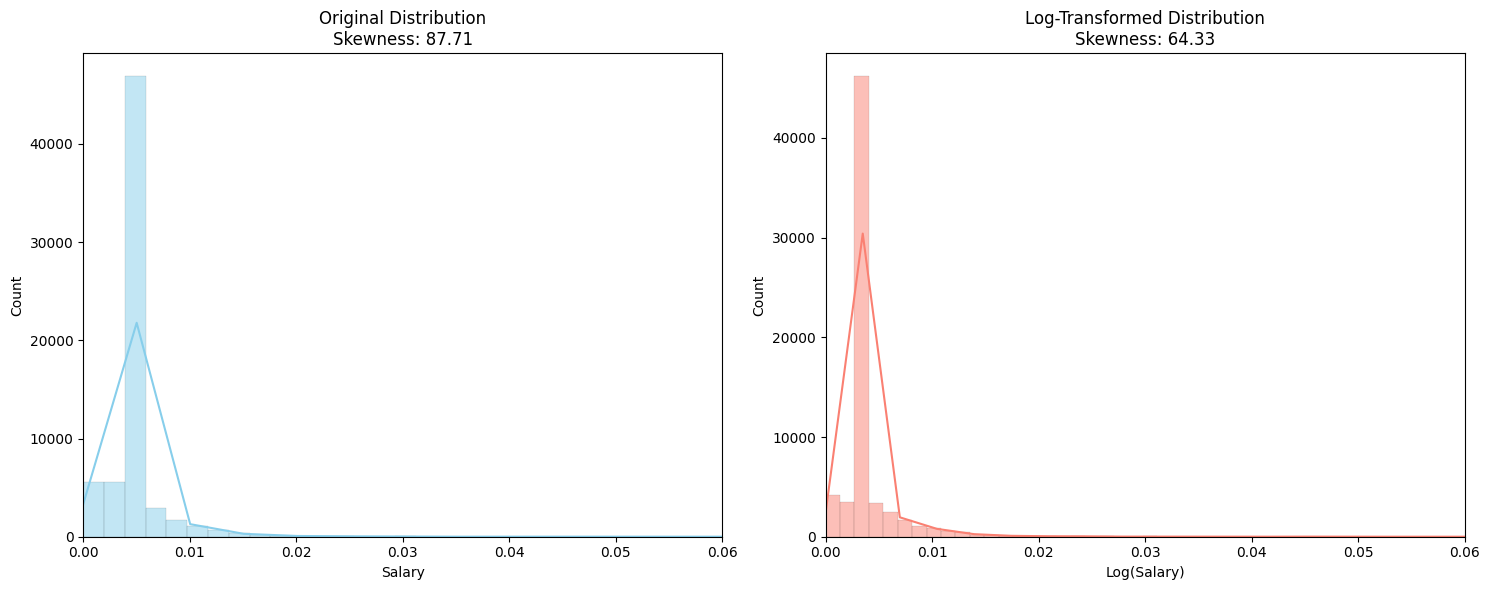

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Original Distribution
sns.histplot(df['ConvertedCompYearly'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_xlim(0, 0.06)
axes[0].set_title(f"Original Distribution\nSkewness: {df['ConvertedCompYearly'].skew():.2f}")
axes[0].set_xlabel("Salary")

# 2. Log-Transformed Distribution
sns.histplot(df['ConvertedCompYearly_log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_xlim(0, 0.06)
axes[1].set_title(f"Log-Transformed Distribution\nSkewness: {df['ConvertedCompYearly_log'].skew():.2f}")
axes[1].set_xlabel("Log(Salary)")

plt.tight_layout()
plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [32]:
## Write your code here
print(df['YearsCodePro'].head(10))
print(f"Current Dtype: {df['YearsCodePro'].dtype}")

0    NaN
1     17
2     27
3    NaN
4    NaN
5    NaN
6      7
7    NaN
8    NaN
9     11
Name: YearsCodePro, dtype: str
Current Dtype: str


In [33]:
df['YearsCodePro'] = df['YearsCodePro'].fillna(0)

In [34]:
print(df['YearsCodePro'].head(10))
print(f"Current Dtype: {df['YearsCodePro'].dtype}")

0     0
1    17
2    27
3     0
4     0
5     0
6     7
7     0
8     0
9    11
Name: YearsCodePro, dtype: object
Current Dtype: object


In [36]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
# errors = 'coerce' turn text to NaN just in case
df['YearsCodePro'].dtype

dtype('float64')

In [38]:
print(df['YearsCodePro'].head(10))
print(f"Current Dtype: {df['YearsCodePro'].dtype}")

0     0.0
1    17.0
2    27.0
3     0.0
4     0.0
5     0.0
6     7.0
7     0.0
8     0.0
9    11.0
Name: YearsCodePro, dtype: float64
Current Dtype: float64


In [ ]:
# convert to in
df['YearsCodePro'] = df['YearsCodePro'].astype(int) 

In [40]:
# Junior: 0-2, Intermediate: 3-5, Senior: 6+
bins = [0, 2, 5, np.inf]
labels = ['Junior', 'Intermediate', 'Senior']

df['ExperienceLevel'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, include_lowest=True)

print(df[['YearsCodePro', 'ExperienceLevel']].head(10))

   YearsCodePro ExperienceLevel
0           0.0          Junior
1          17.0          Senior
2          27.0          Senior
3           0.0          Junior
4           0.0          Junior
5           0.0          Junior
6           7.0          Senior
7           0.0          Junior
8           0.0          Junior
9          11.0          Senior


### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
